<a href="https://colab.research.google.com/github/Naum41k55555/Naumov_Time_-eries/blob/main/practice5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from numpy import asarray

In [7]:
# аналогичным образом загружаем данные о пассажирах
passengers = pd.read_csv('passengers.csv')
# неподходящий формат данных приводим к тому, с которым Pandas может работать
passengers['Month'] = pd.to_datetime(passengers['Month'])
# также устанавливаем индекс и сортируем
df = passengers.set_index('Month').sort_index()

In [8]:
df

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


## Предсказание временного ряда с помощью деревьев

Попробуем обычное дерево решений и случайный лес, а потом сравним результаты

In [9]:
cols = []
for i in range(1, 0, -1):
    cols.append(df.shift(i))
cols

[            Passengers
 Month                 
 1949-01-01         NaN
 1949-02-01       112.0
 1949-03-01       118.0
 1949-04-01       132.0
 1949-05-01       129.0
 ...                ...
 1960-08-01       622.0
 1960-09-01       606.0
 1960-10-01       508.0
 1960-11-01       461.0
 1960-12-01       390.0
 
 [144 rows x 1 columns]]

In [10]:
cols = []
for i in range(1, 0, -1):
    cols.append(df.shift(i))
for i in range(0, 1):
    cols.append(df.shift(-i))
cols

[            Passengers
 Month                 
 1949-01-01         NaN
 1949-02-01       112.0
 1949-03-01       118.0
 1949-04-01       132.0
 1949-05-01       129.0
 ...                ...
 1960-08-01       622.0
 1960-09-01       606.0
 1960-10-01       508.0
 1960-11-01       461.0
 1960-12-01       390.0
 
 [144 rows x 1 columns],
             Passengers
 Month                 
 1949-01-01         112
 1949-02-01         118
 1949-03-01         132
 1949-04-01         129
 1949-05-01         121
 ...                ...
 1960-08-01         606
 1960-09-01         508
 1960-10-01         461
 1960-11-01         390
 1960-12-01         432
 
 [144 rows x 1 columns]]

In [11]:
agg = pd.concat(cols, axis=1)
agg.dropna(inplace=True)
agg

,Passengers,Passengers
Month,,
1949-02-01,112.0,118
1949-03-01,118.0,132
1949-04-01,132.0,129
1949-05-01,129.0,121
1949-06-01,121.0,135
...,...,...
1960-08-01,622.0,606
1960-09-01,606.0,508
1960-10-01,508.0,461


In [12]:
n_vars = 1 if type(df) is list else df.shape[1]
cols = []
for i in range(1, 0, -1):
    cols.append(df.shift(i))
for i in range(0, 1):
    cols.append(df.shift(-i))
# put it all together
agg = pd.concat(cols, axis=1)
agg.dropna(inplace=True)
list_for_forecast = agg.values

In [13]:
len(list_for_forecast)

143

In [14]:
def decision_tree_forecast(train, testX):
    train = asarray(train)
    trainX, trainy = train[:, :-1], train[:, -1]
    model = DecisionTreeRegressor(random_state=0)
    model.fit(trainX, trainy)
    yhat = model.predict([testX])
    return yhat[0]

In [15]:
def random_forest_forecast(train, testX):
    train = asarray(train)
    trainX, trainy = train[:, :-1], train[:, -1]
    model = RandomForestRegressor(n_estimators=1000)
    model.fit(trainX, trainy)
    yhat = model.predict([testX])
    return yhat[0]

In [16]:
predictions = []
size = int(len(list_for_forecast) * 0.66)
train, test = list_for_forecast[0:size], list_for_forecast[size:len(list_for_forecast)]
history = [x for x in train]
history

[array([112., 118.]),
 array([118., 132.]),
 array([132., 129.]),
 array([129., 121.]),
 array([121., 135.]),
 array([135., 148.]),
 array([148., 148.]),
 array([148., 136.]),
 array([136., 119.]),
 array([119., 104.]),
 array([104., 118.]),
 array([118., 115.]),
 array([115., 126.]),
 array([126., 141.]),
 array([141., 135.]),
 array([135., 125.]),
 array([125., 149.]),
 array([149., 170.]),
 array([170., 170.]),
 array([170., 158.]),
 array([158., 133.]),
 array([133., 114.]),
 array([114., 140.]),
 array([140., 145.]),
 array([145., 150.]),
 array([150., 178.]),
 array([178., 163.]),
 array([163., 172.]),
 array([172., 178.]),
 array([178., 199.]),
 array([199., 199.]),
 array([199., 184.]),
 array([184., 162.]),
 array([162., 146.]),
 array([146., 166.]),
 array([166., 171.]),
 array([171., 180.]),
 array([180., 193.]),
 array([193., 181.]),
 array([181., 183.]),
 array([183., 218.]),
 array([218., 230.]),
 array([230., 242.]),
 array([242., 209.]),
 array([209., 191.]),
 array([19

In [17]:
train.dtype(list())

TypeError: 'numpy.dtypes.Float64DType' object is not callable

In [18]:
predictions = []
size = int(len(list_for_forecast) * 0.66)
train, test = list_for_forecast[0:size], list_for_forecast[size:len(list_for_forecast)]
history = [x for x in train]

for i in range(len(test)):
    testX, testy = test[i, :-1], test[i, -1]
    yhat = random_forest_forecast(history, testX)
    predictions.append(yhat)
    history.append(test[i])

error = mean_absolute_error(test[:, -1], predictions)
print("Random Forest error: ", error)

Random Forest error:  46.50511008260446


In [20]:
print("Random Forest metrics: ")
print("RMSE:", np.sqrt(mean_squared_error(test[:, -1], predictions)))
print("MAPE:", mean_absolute_percentage_error(test[:, -1], predictions))
print("MAE:", mean_absolute_error(test[:, -1], predictions))
print("R2: ", r2_score(test[:, -1], predictions))

Random Forest metrics: 
RMSE: 55.33502814756433
MAPE: 0.10931153749503163
MAE: 46.50511008260446
R2:  0.5014245782590798


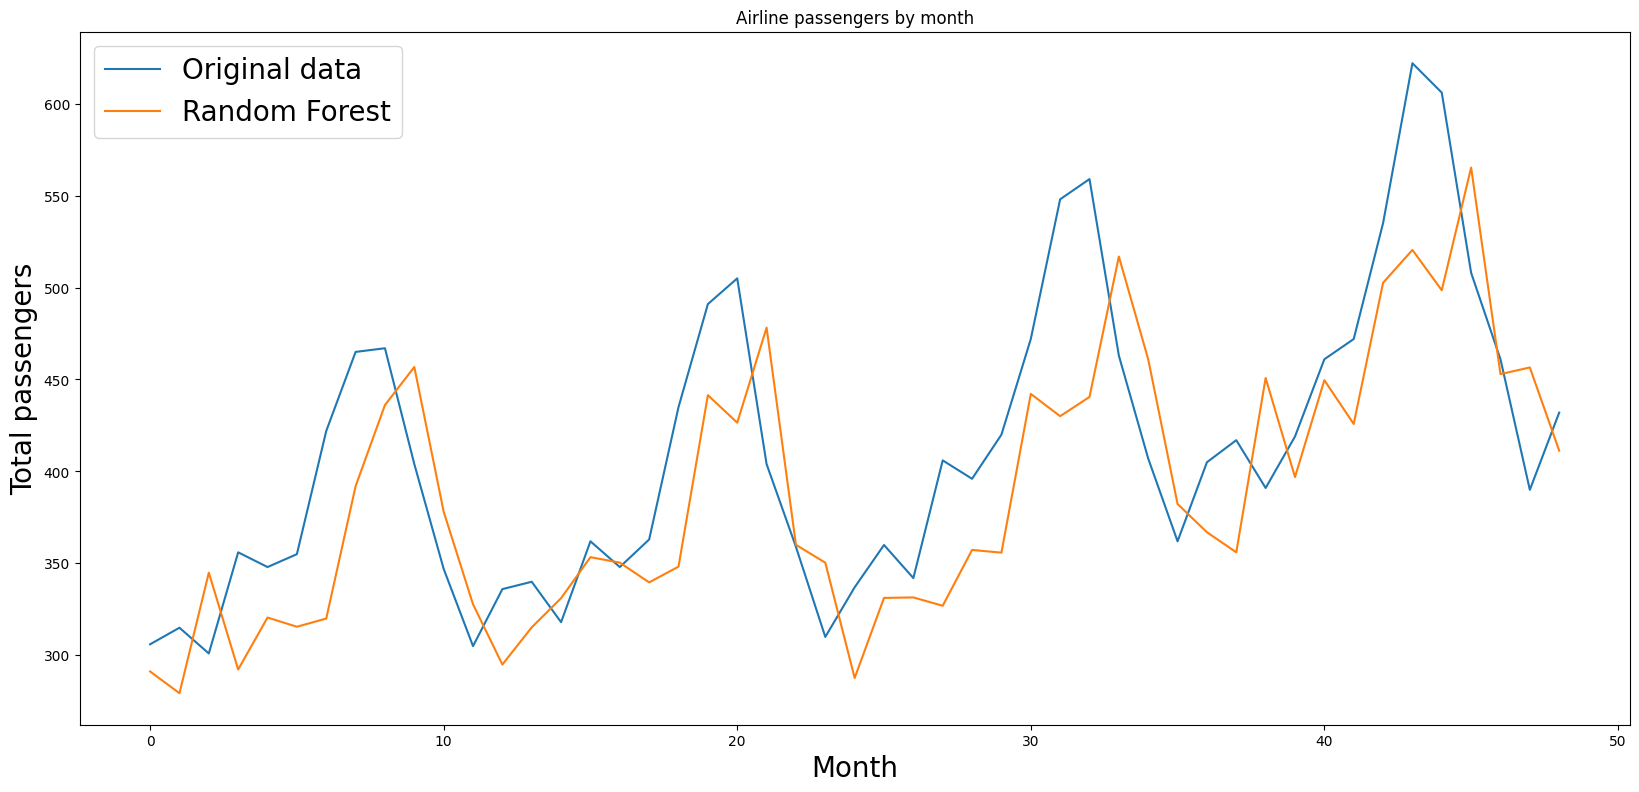

In [21]:
fig = plt.figure(figsize=(20, 9))
plt.plot(test[:, -1], label='Original data')
plt.plot(predictions, label='Random Forest')
plt.legend(fontsize="20")
plt.title('Airline passengers by month')
plt.ylabel('Total passengers', fontsize="20")
plt.xlabel('Month', fontsize="20")
plt.show()

In [22]:
predictions = list()
size = int(len(list_for_forecast) * 0.66)
train, test = list_for_forecast[0:size], list_for_forecast[size:len(list_for_forecast)]
history = [x for x in train]

for i in range(len(test)):
    testX, testy = test[i, :-1], test[i, -1]
    yhat = decision_tree_forecast(history, testX)
    predictions.append(yhat)
    history.append(test[i])


In [23]:
print("Decision Forest metrics: ")
print("RMSE:", np.sqrt(mean_squared_error(test[:, -1], predictions)))
print("MAPE:", mean_absolute_percentage_error(test[:, -1], predictions))
print("MAE:", mean_absolute_error(test[:, -1], predictions))
print("R2: ", r2_score(test[:, -1], predictions))

Decision Forest metrics: 
RMSE: 65.29403666867132
MAPE: 0.12270617535711836
MAE: 52.1530612244898
R2:  0.3058111520951716


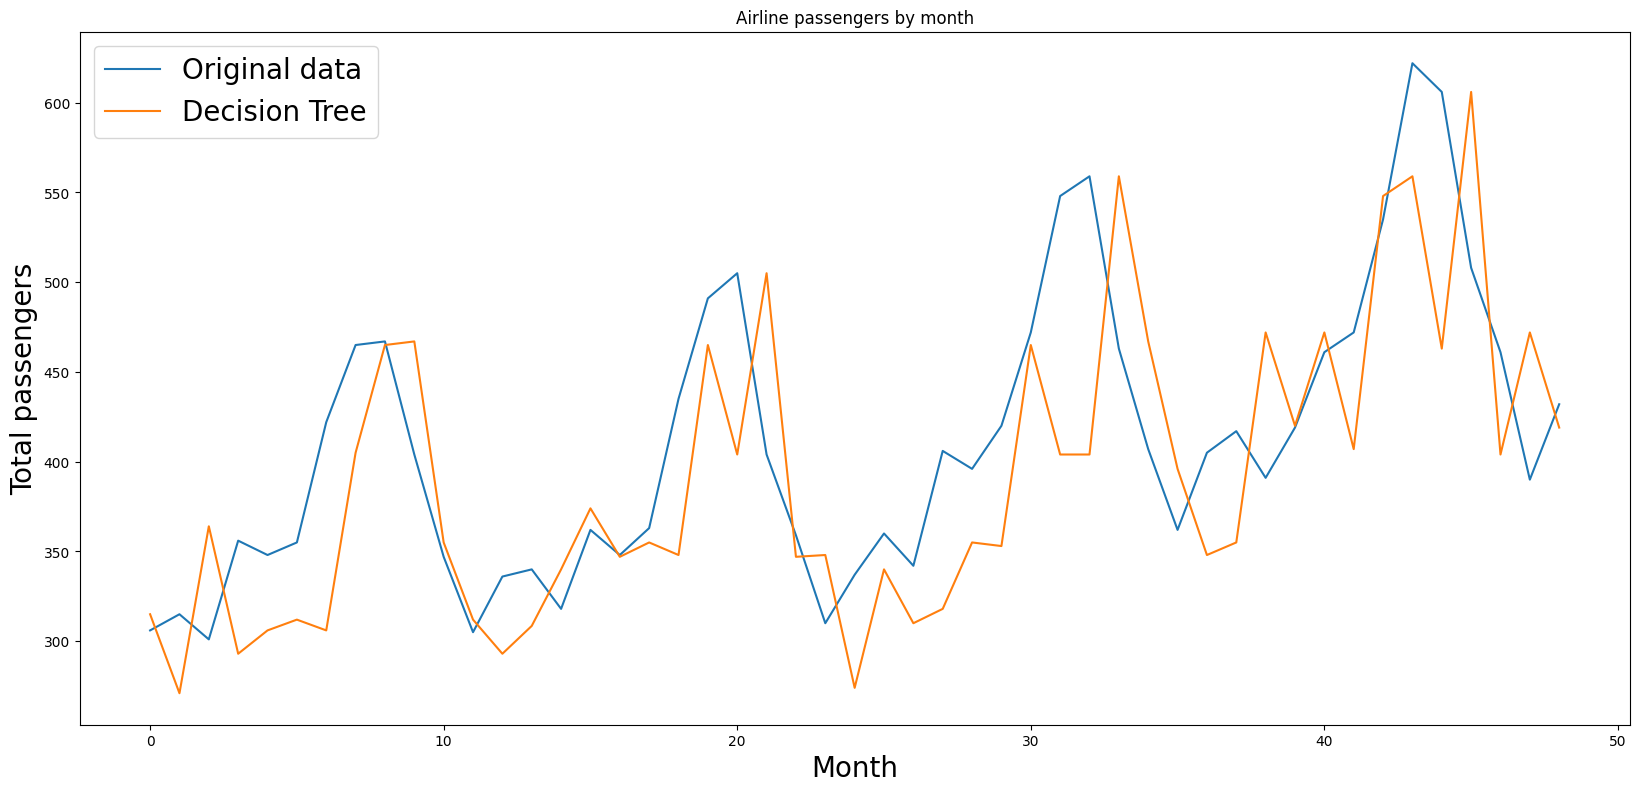

In [24]:
fig = plt.figure(figsize=(20, 9))
plt.plot(test[:, -1], label='Original data')
plt.plot(predictions, label='Decision Tree')
plt.legend(fontsize="20")
plt.title('Airline passengers by month')
plt.ylabel('Total passengers', fontsize="20")
plt.xlabel('Month', fontsize="20")
plt.show()

## Детекция аномалий с помощью isolated forest

In [25]:
from sklearn.ensemble import IsolationForest

In [27]:
# аналогичным образом загружаем данные о пассажирах
pas = pd.read_csv('passengers.csv')
# неподходящий формат данных приводим к тому, с которым Pandas может работать
pas['Month'] = pd.to_datetime(passengers['Month'])
# также устанавливаем индекс и сортируем
pas

,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [28]:
model = IsolationForest(contamination=0.004)
model.fit(pas[['Passengers']])

IsolationForest(contamination=0.004)

In [29]:
pas['outliers'] = pd.Series(model.predict(pas[['Passengers']])).apply(lambda x: 'yes' if (x == -1) else 'no' )

In [30]:
pas.query('outliers=="yes"')

,Month,Passengers,outliers
138,1960-07-01,622,yes


In [31]:
fig = px.scatter(pas.reset_index(), x='Month', y='Passengers', color='outliers')
fig.update_xaxes(
    rangeslider_visible=True,
)
fig.show()

## Самостоятельная работа

**Задание 1: Учет сезонности (больше лагов)**
В нашем прошлом примере мы брали сдвиг всего на один месяц (`lag = 1`). В данных авиаперевозок есть очевидная годовая сезонность.
Измените код так, чтобы модель смотрела на 12 предыдущих месяцев одновременно. Сформируйте выборку, обучите `RandomForest` с помощью функции `random_forest_forecast` и выведите метрики. Сравните, как изменились результаты.


Random Forest (12 лагов):
RMSE: 33.56742184387184
MAPE: 0.06323094878315537
MAE:  26.881288888888893
R2:   0.8067353895153039


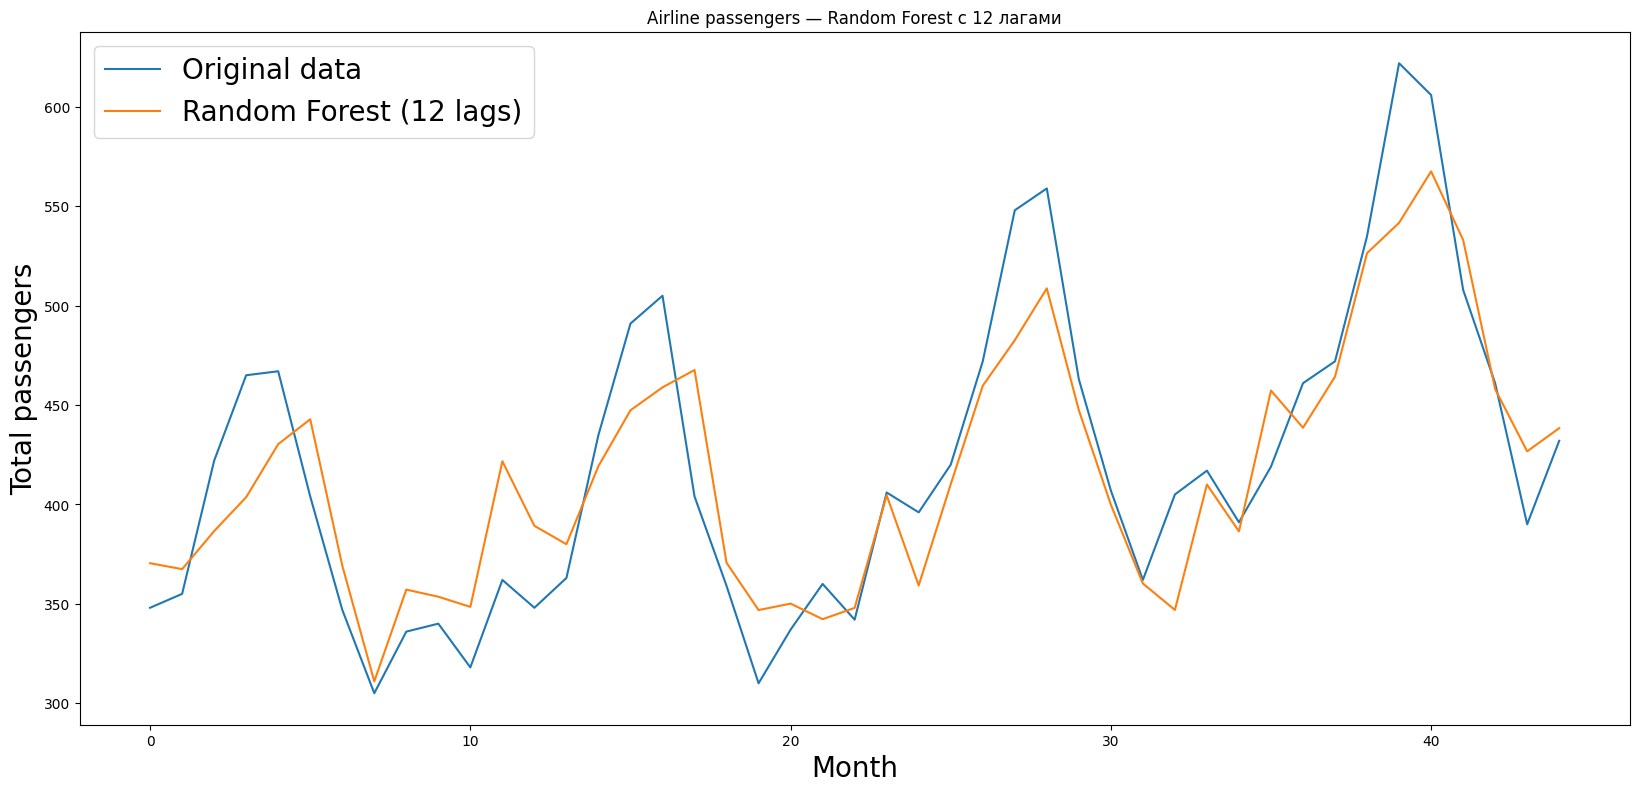

In [19]:
# Задание 1: RandomForest с 12 лагами (учет сезонности)

# Формируем датасет со сдвигами (12 лагов)
num_lags = 12
lagged_features = []

# Собираем прошлые значения
for shift_val in range(num_lags, 0, -1):
    lagged_features.append(df.shift(shift_val))

# Добавляем целевую переменную (текущее значение)
lagged_features.append(df)

# Объединяем и очищаем от пустых строк
dataset_agg = pd.concat(lagged_features, axis=1)
dataset_agg.dropna(inplace=True)
matrix_data = dataset_agg.values

# Настройка Walk-Forward валидации
split_point = int(len(matrix_data) * 0.66)
train_records, test_records = matrix_data[:split_point], matrix_data[split_point:]

rolling_history = list(train_records)
rf_predictions = []

# Пошаговое прогнозирование
for step in range(len(test_records)):
    features_x, target_y = test_records[step, :-1], test_records[step, -1]

    predicted_val = random_forest_forecast(rolling_history, features_x)
    rf_predictions.append(predicted_val)

    rolling_history.append(test_records[step])

# Расчет и вывод метрик эффективности
actual_values = test_records[:, -1]

print('Random Forest (12 лагов):')
print('RMSE:', np.sqrt(mean_squared_error(actual_values, rf_predictions)))
print('MAPE:', mean_absolute_percentage_error(actual_values, rf_predictions))
print('MAE: ', mean_absolute_error(actual_values, rf_predictions))
print('R2:  ', r2_score(actual_values, rf_predictions))

# Визуализация результатов
fig = plt.figure(figsize=(20, 9))
plt.plot(actual_values, label='Original data')
plt.plot(rf_predictions, label='Random Forest (12 lags)')
plt.legend(fontsize='20')
plt.title('Airline passengers — Random Forest с 12 лагами')
plt.ylabel('Total passengers', fontsize='20')
plt.xlabel('Month', fontsize='20')
plt.show()

**Задание 2: Сравнение деревьев с «глупым» бейзлайном (Naive Forecast)**
Чтобы понимать, насколько вообще полезно применять Random Forest, нужен ориентир (baseline). Напишите простую «наивную» модель: в качестве прогноза на следующий шаг берется просто значение предыдущего шага ($\hat{y}_t = y_{t-1}$).
Сравните $R^2$ и $MAE$ наивного прогноза с вашим лесом из Задания 1.

In [35]:
# Задание 2: Naive Forecast (бейзлайн)

# Наивный прогноз: следующее значение равно предыдущему y(t) = y(t-1)
# Берем ту же тестовую выборку для корректности сопоставления результатов
naive_preds = []

for step in range(len(test_records)):
    # Поскольку последняя колонка — таргет (t), колонка перед ней (-2) является значением t-1
    prev_value = test_records[step, -2]
    naive_preds.append(prev_value)

# Выделяем истинные значения для удобства расчетов
true_targets = test_records[:, -1]

# Расчет метрик для обеих моделей
mae_naive = mean_absolute_error(true_targets, naive_preds)
r2_naive = r2_score(true_targets, naive_preds)

mae_rf = mean_absolute_error(true_targets, rf_predictions)
r2_rf = r2_score(true_targets, rf_predictions)

# Вывод результатов сравнения
print('Naive Forecast (baseline):')
print(f'MAE:  {mae_naive}')
print(f'R2:   {r2_naive}\n')

print('Random Forest (12 лагов):')
print(f'MAE:  {mae_rf}')
print(f'R2:   {r2_rf}\n')

# Сравнительный анализ по коэффициенту детерминации
if r2_rf > r2_naive:
    print('=> Random Forest лучше наивного прогноза')
else:
    print('=> Наивный прогноз не хуже Random Forest')

Naive Forecast (baseline):
MAE:  40.977777777777774
R2:   0.59033250438754

Random Forest (12 лагов):
MAE:  26.881288888888893
R2:   0.8067353895153039

=> Random Forest лучше наивного прогноза


**Задание 3: Чувствительность алгоритма поиска аномалий**
В конце практики мы использовали алгоритм `IsolationForest` для поиска аномалий с крайне низким параметром `contamination=0.004`.
Измените этот параметр на `0.05` (поиск 5% самых аномальных периодов), обучите модель заново и отрисуйте график с новыми подсвеченными точками. Как поменялась картина, какие теперь месяцы считаются "нетипичными"?


In [34]:
# Задание 3: IsolationForest с contamination=0.05

# Инициализируем и обучаем модель Isolation Forest с уровнем аномалий 5%
iso_forest_05 = IsolationForest(contamination=0.05, random_state=42)
iso_forest_05.fit(pas[['Passengers']])

# Определяем выбросы: -1 соответствует аномалии ('yes'), 1 — норме ('no')
raw_predictions = iso_forest_05.predict(pas[['Passengers']])
pas['outliers_05'] = ['yes' if marker == -1 else 'no' for marker in raw_predictions]

# Отображение найденных аномальных периодов
print('Аномальные месяцы (contamination=0.05):')
print(pas.query('outliers_05 == "yes"')[['Month', 'Passengers']])

# Построение интерактивного графика рассеяния
fig = px.scatter(
    pas.reset_index(),
    x='Month',
    y='Passengers',
    color='outliers_05',
    title='IsolationForest (contamination=0.05)'
)
fig.update_xaxes(rangeslider_visible=True)
fig.show()

print()

# Сравнительный анализ количества обнаруженных выбросов при разных порогах
anomalies_count_004 = len(pas.query("outliers == 'yes'"))
anomalies_count_05 = len(pas.query("outliers_05 == 'yes'"))

print(f'При contamination=0.004 аномалий: {anomalies_count_004}')
print(f'При contamination=0.05 аномалий:  {anomalies_count_05}')
print('С повышенным contamination модель находит больше "нетипичных" месяцев — как правило, это месяцы с наибольшим числом пассажиров (пики сезонности).')

Аномальные месяцы (contamination=0.05):
         Month  Passengers
10  1949-11-01         104
114 1958-07-01         491
126 1959-07-01         548
127 1959-08-01         559
137 1960-06-01         535
138 1960-07-01         622
139 1960-08-01         606
140 1960-09-01         508



При contamination=0.004 аномалий: 1
При contamination=0.05 аномалий:  8
С повышенным contamination модель находит больше "нетипичных" месяцев — как правило, это месяцы с наибольшим числом пассажиров (пики сезонности).
